<a href="https://colab.research.google.com/github/kavyasree4494/project1/blob/main/E_Commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the Excel file into a pandas DataFrame
df = pd.read_excel('/content/Ecommerce_Sales_Dataset.xlsx')

# Display the first 5 rows of the DataFrame
display(df.head())

,OrderID,OrderDate,CustomerID,Region,Category,Product,Quantity,UnitPrice,TotalAmount,PaymentMethod
0,ORD100000,2023-12-25,CUST10535,West,Fashion,Formal Shirt,1,1375.76,1375.76,Debit Card
1,ORD100001,2023-06-06,CUST14643,West,Fashion,Denim Jeans,1,1811.95,1630.76,Credit Card
2,ORD100002,2024-02-05,CUST13927,North,Fashion,Winter Jacket,1,3431.87,3431.87,UPI
3,ORD100003,2024-02-09,CUST12633,South,Electronics,Bluetooth Speaker,3,783.88,2234.06,Credit Card
4,ORD100004,2023-01-01,CUST12598,East,Electronics,Laptop Stand,1,4982.24,4982.24,Cash on Delivery


In [2]:
# Display the shape of the DataFrame
print("DataFrame Shape:", df.shape)

DataFrame Shape: (20000, 10)


In [3]:
# Display information about the DataFrame, including data types and memory usage
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        20000 non-null  object 
 1   OrderDate      20000 non-null  object 
 2   CustomerID     20000 non-null  object 
 3   Region         19920 non-null  object 
 4   Category       20000 non-null  object 
 5   Product        20000 non-null  object 
 6   Quantity       20000 non-null  int64  
 7   UnitPrice      20000 non-null  float64
 8   TotalAmount    20000 non-null  float64
 9   PaymentMethod  19850 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 1.5+ MB


In [4]:
# Display the last 5 rows of the DataFrame
print("\nLast 5 rows of the DataFrame:")
display(df.tail())


Last 5 rows of the DataFrame:


,OrderID,OrderDate,CustomerID,Region,Category,Product,Quantity,UnitPrice,TotalAmount,PaymentMethod
19995,ORD113303,2024-07-03,CUST15935,North,Fashion,Leather Wallet,1,2535.57,2535.57,Credit Card
19996,ORD117988,2024-08-13,CUST10241,North,Sports,Cricket Bat,1,468.96,422.06,Debit Card
19997,ORD118709,2024-07-04,CUST14116,North,Grocery,Organic Rice 5kg,1,970.23,776.18,Cash on Delivery
19998,ORD104464,2023-11-18,CUST12674,North,Beauty,Sunscreen SPF50,1,1151.94,1151.94,UPI
19999,ORD107233,2024-07-05,CUST12193,North,Electronics,Wireless Earbuds,1,2379.22,2379.22,Credit Card


In [5]:
# Display descriptive statistics for all columns, including non-numeric ones
print("\nDescriptive Statistics:")
display(df.describe(include='all'))


Descriptive Statistics:


,OrderID,OrderDate,CustomerID,Region,Category,Product,Quantity,UnitPrice,TotalAmount,PaymentMethod
count,20000,20000,20000,19920,20000,20000,20000.000000,20000.000000,20000.000000,19850
unique,19975,731,5772,4,7,56,NaN,NaN,NaN,6
top,ORD119051,2024-04-22,CUST14697,North,Electronics,Wireless Earbuds,NaN,NaN,NaN,Credit Card
freq,2,47,12,5012,4435,590,NaN,NaN,NaN,5507
mean,NaN,NaN,NaN,NaN,NaN,NaN,1.475500,1625.732023,2276.102438,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.879965,1208.879513,2406.553987,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,49.650000,39.190000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,635.335000,723.477500,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1260.895000,1565.590000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2498.327500,2939.240000,NaN


In [7]:
# Task 2: Handle Missing Values

# Find which columns have missing values and how many
print("Missing values before handling:")
print(df.isna().sum())

# Fill missing 'Region' with 'Unknown'
df['Region'].fillna('Unknown', inplace=True)

# Fill missing 'PaymentMethod' with the most frequent payment method (mode)
mode_payment_method = df['PaymentMethod'].mode()[0]
df['PaymentMethod'].fillna(mode_payment_method, inplace=True)

print("\nMissing values after handling:")
print(df.isna().sum())

Missing values before handling:
OrderID          0
OrderDate        0
CustomerID       0
Region           0
Category         0
Product          0
Quantity         0
UnitPrice        0
TotalAmount      0
PaymentMethod    0
dtype: int64

Missing values after handling:
OrderID          0
OrderDate        0
CustomerID       0
Region           0
Category         0
Product          0
Quantity         0
UnitPrice        0
TotalAmount      0
PaymentMethod    0
dtype: int64


In [8]:
# Task 3: Remove Duplicate Records

# Detect duplicate rows and report how many exist
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate records found: {duplicates_count}")

# Remove duplicate rows
df_clean = df.drop_duplicates()

# Verify that no duplicate records remain
print(f"Number of duplicate records after removal: {df_clean.duplicated().sum()}")

# Assign the cleaned DataFrame back to df for subsequent tasks
df = df_clean.copy()
print(f"DataFrame shape after removing duplicates: {df.shape}")

Number of duplicate records found: 25
Number of duplicate records after removal: 0
DataFrame shape after removing duplicates: (19975, 10)


In [9]:
# Task 4: Fix Data Types

# Convert 'OrderDate' to a proper datetime type
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Create new 'OrderMonth' and 'OrderYear' columns
df['OrderMonth'] = df['OrderDate'].dt.month_name()
df['OrderYear'] = df['OrderDate'].dt.year

print("DataFrame Info after fixing data types and adding new columns:")
df.info()
print("\nFirst 5 rows with new 'OrderMonth' and 'OrderYear' columns:")
display(df.head())

DataFrame Info after fixing data types and adding new columns:
<class 'pandas.core.frame.DataFrame'>
Index: 19975 entries, 0 to 19974
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        19975 non-null  object        
 1   OrderDate      19975 non-null  datetime64[ns]
 2   CustomerID     19975 non-null  object        
 3   Region         19975 non-null  object        
 4   Category       19975 non-null  object        
 5   Product        19975 non-null  object        
 6   Quantity       19975 non-null  int64         
 7   UnitPrice      19975 non-null  float64       
 8   TotalAmount    19975 non-null  float64       
 9   PaymentMethod  19975 non-null  object        
 10  OrderMonth     19975 non-null  object        
 11  OrderYear      19975 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(7)
memory usage: 1.9+ MB

First 5 rows with new 'Orde

,OrderID,OrderDate,CustomerID,Region,Category,Product,Quantity,UnitPrice,TotalAmount,PaymentMethod,OrderMonth,OrderYear
0,ORD100000,2023-12-25,CUST10535,West,Fashion,Formal Shirt,1,1375.76,1375.76,Debit Card,December,2023
1,ORD100001,2023-06-06,CUST14643,West,Fashion,Denim Jeans,1,1811.95,1630.76,Credit Card,June,2023
2,ORD100002,2024-02-05,CUST13927,North,Fashion,Winter Jacket,1,3431.87,3431.87,UPI,February,2024
3,ORD100003,2024-02-09,CUST12633,South,Electronics,Bluetooth Speaker,3,783.88,2234.06,Credit Card,February,2024
4,ORD100004,2023-01-01,CUST12598,East,Electronics,Laptop Stand,1,4982.24,4982.24,Cash on Delivery,January,2023


In [10]:
# Task 5: Revenue by Category

# Calculate the total TotalAmount generated by each Category and sort it
revenue_by_category = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)

print("Total Revenue by Category (sorted highest to lowest):")
display(revenue_by_category)

# Identify the top 3 categories by revenue
print("\nTop 3 Categories by Revenue:")
display(revenue_by_category.head(3))

Total Revenue by Category (sorted highest to lowest):


,TotalAmount
Category,
Electronics,16637101.98
Fashion,10291758.80
Home & Kitchen,6409462.66
Sports,6242873.76
Beauty,2962151.51
Grocery,1486088.16
Books,1440845.17



Top 3 Categories by Revenue:


,TotalAmount
Category,
Electronics,16637101.98
Fashion,10291758.80
Home & Kitchen,6409462.66


In [11]:
# Task 6: Regional Performance Summary

# Create a summary table showing, for each Region: total revenue, number of orders, and average order value
regional_performance = df.groupby('Region').agg(
    Total_Revenue=('TotalAmount', 'sum'),
    Orders=('OrderID', 'count'),
    Avg_Order_Value=('TotalAmount', 'mean')
).round(2)

print("Regional Performance Summary:")
display(regional_performance)

Regional Performance Summary:


,Total_Revenue,Orders,Avg_Order_Value
Region,,,
East,11220270.41,5004,2242.26
North,11321013.44,5002,2263.30
South,11650112.94,4958,2349.76
Unknown,177728.19,80,2221.60
West,11101157.06,4931,2251.30


In [12]:
# Task 7: Most Popular Products

# Find the top 10 products by total quantity sold
most_popular_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(10)

print("Top 10 Most Popular Products by Quantity Sold:")
display(most_popular_products)

Top 10 Most Popular Products by Quantity Sold:


,Quantity
Product,
Wireless Earbuds,897
Laptop Stand,826
USB-C Cable,822
Smartwatch,821
Smartphone Case,812
Webcam,810
Bluetooth Speaker,800
Sunglasses,776
Power Bank,765


In [13]:
# Task 8: Monthly Sales Trend

# Create a 'YearMonth' column
df['YearMonth'] = df['OrderDate'].dt.to_period('M')

# Compute total revenue for each Year-Month combination
monthly_sales_trend = df.groupby('YearMonth')['TotalAmount'].sum()

# Convert the 'YearMonth' index to datetime for easier plotting later
monthly_sales_trend.index = monthly_sales_trend.index.to_timestamp()

print("Monthly Sales Trend (Total Revenue):")
display(monthly_sales_trend)

Monthly Sales Trend (Total Revenue):


,TotalAmount
YearMonth,
2023-01-01,1811221.85
2023-02-01,1780493.19
2023-03-01,1874014.66
2023-04-01,2026960.14
2023-05-01,1911494.17
2023-06-01,1878274.25
2023-07-01,1905700.67
2023-08-01,1870680.13
2023-09-01,1814877.66


In [14]:
# Task 9: Payment Method Preferences

# Determine what percentage of total orders used each PaymentMethod
payment_method_percentage = df['PaymentMethod'].value_counts(normalize=True) * 100

print("Percentage of Orders by Payment Method:")
display(payment_method_percentage.round(2))

Percentage of Orders by Payment Method:


,proportion
PaymentMethod,
Credit Card,28.27
UPI,26.90
Debit Card,18.18
Cash on Delivery,13.51
Net Banking,8.26
Wallet,4.89


In [15]:
# Task 10: High-Value Customers

# Identify the top 10 customers by total amount spent and how many orders each placed
high_value_customers = df.groupby('CustomerID').agg(
    Total_Spent=('TotalAmount', 'sum'),
    Orders=('OrderID', 'count')
).sort_values('Total_Spent', ascending=False).head(10)

print("Top 10 High-Value Customers:")
display(high_value_customers)

Top 10 High-Value Customers:


,Total_Spent,Orders
CustomerID,,
CUST10158,44790.30,4
CUST10142,44101.10,9
CUST12728,43793.70,7
CUST11668,37637.87,10
CUST14400,37183.45,9
CUST11351,36948.61,4
CUST13019,36080.14,5
CUST12481,35477.63,8
CUST13605,35292.80,6


In [16]:
# Task 11: Filter High-Value Orders

# Calculate the 90th percentile of TotalAmount
threshold = df['TotalAmount'].quantile(0.90)
print(f"90th percentile of TotalAmount: {threshold:.2f}")

# Extract all orders where TotalAmount is greater than the 90th percentile
premium_orders = df[df['TotalAmount'] > threshold]

print(f"Number of premium orders found: {len(premium_orders)}")
print("\nHead of Premium Orders DataFrame:")
display(premium_orders.head())

90th percentile of TotalAmount: 4769.09
Number of premium orders found: 1998

Head of Premium Orders DataFrame:


,OrderID,OrderDate,CustomerID,Region,Category,Product,Quantity,UnitPrice,TotalAmount,PaymentMethod,OrderMonth,OrderYear,YearMonth
4,ORD100004,2023-01-01,CUST12598,East,Electronics,Laptop Stand,1,4982.24,4982.24,Cash on Delivery,January,2023,2023-01
13,ORD100013,2024-09-24,CUST14566,West,Electronics,Power Bank,2,3402.96,6805.92,Credit Card,September,2024,2024-09
22,ORD100022,2023-04-20,CUST11095,East,Electronics,Smartwatch,3,4183.06,10666.80,UPI,April,2023,2023-04
28,ORD100028,2024-01-14,CUST13272,South,Electronics,Bluetooth Speaker,2,2941.10,5588.09,Credit Card,January,2024,2024-01
37,ORD100037,2024-01-22,CUST14965,North,Electronics,Laptop Stand,2,4490.07,8980.14,Debit Card,January,2024,2024-01


In [17]:
# Task 12: Create a Price-Band Column

# Define price ranges and labels
bins = [0, 100, 500, 2000, df['UnitPrice'].max()]
labels = ['Low', 'Medium', 'High', 'Premium']

# Create the 'Price_Band' column using pd.cut
df['Price_Band'] = pd.cut(df['UnitPrice'], bins=bins, labels=labels, right=False)

print("Distribution of orders across Price Bands:")
display(df['Price_Band'].value_counts())

Distribution of orders across Price Bands:


,count
Price_Band,
High,9534
Premium,6833
Medium,3481
Low,126


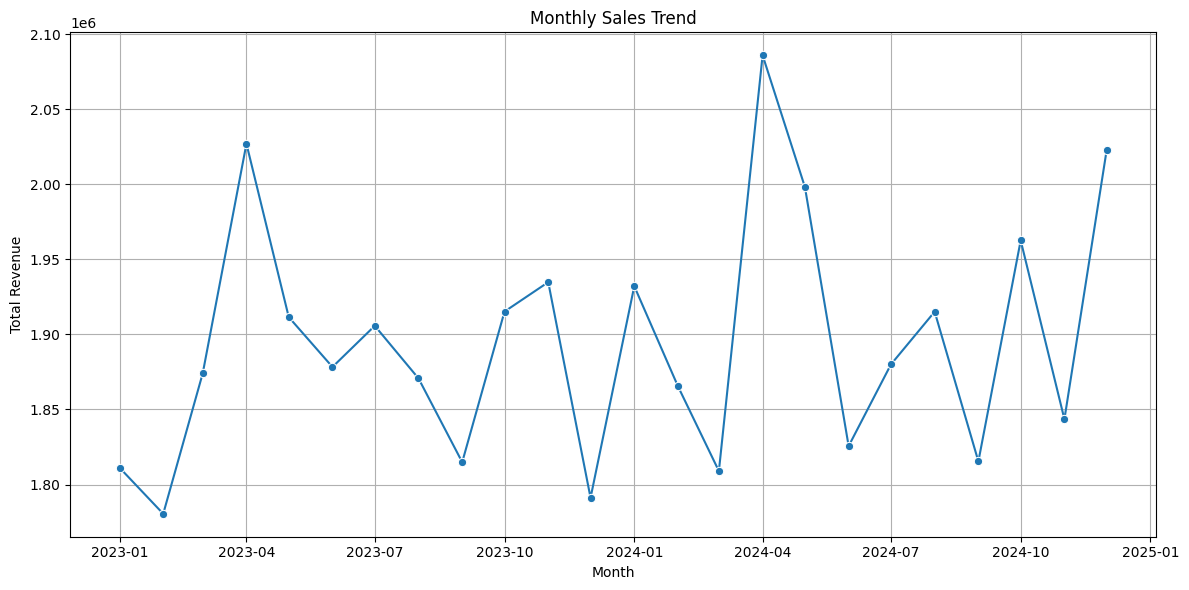

In [19]:
# Task 14: Line Chart: Monthly Sales Trend

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_sales_trend.index, y=monthly_sales_trend.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()

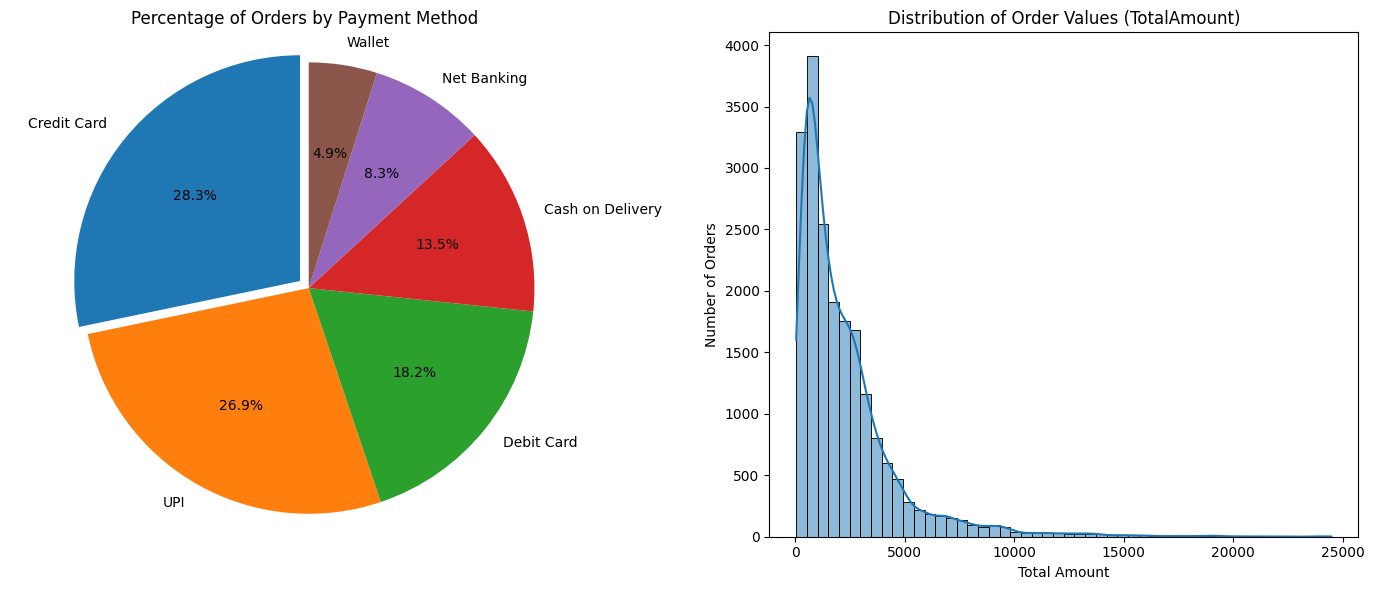

In [20]:
# Task 15: Pie Chart & Histogram: Payment Methods and Order Values

# Pie Chart for Payment Methods
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.pie(payment_method_percentage.values,
        labels=payment_method_percentage.index,
        autopct='%1.1f%%',
        startangle=90,
        explode=[0.05 if p == payment_method_percentage.max() else 0 for p in payment_method_percentage.values]
       )
plt.title('Percentage of Orders by Payment Method')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# Histogram for Order Values (TotalAmount)
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(df['TotalAmount'], bins=50, kde=True)
plt.title('Distribution of Order Values (TotalAmount)')
plt.xlabel('Total Amount')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

Business Insights


Data Quality is Crucial: We identified and addressed missing values in 'Region' and 'PaymentMethod', and removed duplicate records. This highlights the importance of data cleaning for accurate analysis. (Tasks 1, 2, 3, 4)

Category Performance: 'Electronics', 'Fashion', and 'Home & Kitchen' are the top three revenue-generating categories. This suggests these categories are key drivers of sales and should be prioritized in marketing and inventory management. (Task 5)

Regional Disparities: There are clear differences in total revenue, number of orders, and average order value across regions. Targeted regional strategies could be developed to optimize sales in underperforming areas or capitalize further on strong regions. The 'Unknown' region also had some activity, indicating a need to improve data collection for regional information. (Task 6)

Popular Products: 'Wireless Earbuds', 'Laptop Stand', and 'USB-C Cable' are among the most popular products by quantity sold. This information can guide inventory stocking, promotional offers, and product bundling strategies. (Task 7)

Monthly Sales Trends: We observed fluctuations in monthly sales, which can be critical for forecasting, resource allocation, and planning promotional campaigns around peak seasons. (Task 8 & Task 14 - Line Chart)

Payment Method Preferences: 'Credit Card' and 'UPI' are the most preferred payment methods. Ensuring seamless integration and promotional offers for these methods can enhance customer experience and conversion rates. (Task 9 & Task 15 - Pie Chart)

High-Value Customers: We identified the top 10 customers based on their total spending and order count. These customers are vital for the business and could be targeted with loyalty programs, exclusive offers, or personalized communications to foster retention. (Task 10)

Premium Orders Analysis: Orders exceeding the 90th percentile of 'TotalAmount' represent a significant portion of revenue. Understanding the characteristics of these premium orders can inform strategies for upselling and targeting high-spending customers. (Task 11)

Price Band Insights: The distribution of orders across 'Low', 'Medium', 'High', and 'Premium' price bands helps in understanding customer purchasing power and product positioning. For instance, 'High' and 'Premium' bands account for a large number of orders, indicating a market for higher-priced items.

Project Summary

This project involved a comprehensive analysis of an E-Commerce Sales Dataset, encompassing data loading, cleaning, exploration, aggregation, feature engineering, and visualization. We processed 20,000 initial records, handled missing values, removed duplicates, and corrected data types. Subsequently, we extracted valuable insights into sales performance by category, region, product, and over time, identified payment method preferences, and pinpointed high-value customers. Finally, we engineered a 'Price-Band' feature and created several visualizations to effectively communicate these findings.